# 05 · Modelado

**Objetivo.** Entrenar y evaluar dos modelos de clasificación para detectar fraude — `LogisticRegression` y
`RandomForestClassifier` (scikit-learn, sin XGBoost/LightGBM ni otras librerías de boosting) — usando el train/test
generado en `02_limpieza.ipynb` (split estratificado 80/20, sin fuga de información) y las features construidas en
`03_feature_engineering.ipynb`.

**Estrategia de balanceo.** Según lo decidido en `04_balanceo.ipynb`, usamos `class_weight='balanced'` en ambos
modelos — no se aplica SMOTE ni ninguna otra técnica de oversampling sobre estos datos.

**Estructura de este notebook:**
1. Carga de datos y preparación (escalado solo para la regresión logística).
2. Modelos "antes" (poco o nada regularizados) + validación cruzada estratificada con métricas de train y de
   validación por fold → diagnóstico de overfitting.
3. Modelos "después" (con mitigación de overfitting) + misma validación cruzada, para comparar el efecto.
4. Evaluación final de los modelos mitigados sobre el **holdout de test real** del proyecto (nunca visto durante
   entrenamiento ni CV), con todas las métricas pedidas y matriz de confusión.
5. Comparación explícita train vs. test del modelo final.
6. Interpretabilidad: importancia de features (Random Forest) y coeficientes (Logistic Regression).
7. Guardado del modelo final y conclusión.

In [1]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100


## 1. Carga de datos

Cargamos train y test ya procesados (mismas 274 columnas de features en ambos, sin fugas: todo lo que aprendieron los notebooks 02/03 se ajustó solo con el train).

In [2]:
with open("../data/processed/artifacts/feature_columns.json", encoding="utf-8") as f:
    feature_cols = json.load(f)

train = pd.read_parquet("../data/processed/train_fe.parquet")
test = pd.read_parquet("../data/processed/test_fe.parquet")

X_train, y_train = train[feature_cols], train["isFraud"]
X_test, y_test = test[feature_cols], test["isFraud"]

print("train:", X_train.shape, "| tasa fraude:", y_train.mean().round(4))
print("test: ", X_test.shape, "| tasa fraude:", y_test.mean().round(4))


train: (472432, 274) | tasa fraude: 0.035
test:  (118108, 274) | tasa fraude: 0.035


Escalamos las features solo para `LogisticRegression` (sensible a la escala de las variables; `RandomForestClassifier`
no lo necesita porque sus splits son invariantes a transformaciones monótonas de cada columna). El `StandardScaler`
se ajusta **solo con `X_train`** y se aplica igual a `X_test`.

In [3]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 2. Modelos "antes" (sin mitigar overfitting) + validación cruzada

- `LogisticRegression` con `C=100` (regularización muy débil).
- `RandomForestClassifier` con `n_estimators=100` y **sin límite de profundidad** (`max_depth=None`), el valor por
  defecto de scikit-learn — los árboles crecen hasta que las hojas son puras, lo que en un dataset de ~380k filas por
  fold tiende a memorizar el ruido del train.

Usamos `cross_validate(..., return_train_score=True)`: en la misma corrida de 5-fold CV obtenemos tanto el score en
el fold de entrenamiento como en el fold de validación, lo que nos da de forma directa el diagnóstico de overfitting
por validación cruzada (no solo un único split).

In [4]:
logit_before = LogisticRegression(C=100.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
rf_before = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)

t0 = time.time()
cv_logit_before = cross_validate(
    logit_before, X_train_s, y_train, cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=1,
)
print(f"CV LogisticRegression (antes): {time.time()-t0:.1f}s")

t0 = time.time()
cv_rf_before = cross_validate(
    rf_before, X_train, y_train, cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=1,
)
print(f"CV RandomForest (antes): {time.time()-t0:.1f}s")


CV LogisticRegression (antes): 143.3s


CV RandomForest (antes): 213.0s


In [5]:
def cv_summary(cv_result, model_name):
    rows = []
    for metric in scoring:
        rows.append({
            "modelo": model_name,
            "metrica": metric,
            "train (CV)": cv_result[f"train_{metric}"].mean(),
            "val (CV)": cv_result[f"test_{metric}"].mean(),
            "gap (train-val)": cv_result[f"train_{metric}"].mean() - cv_result[f"test_{metric}"].mean(),
        })
    return pd.DataFrame(rows)

summary_before = pd.concat([
    cv_summary(cv_logit_before, "LogisticRegression (antes, C=100)"),
    cv_summary(cv_rf_before, "RandomForest (antes, sin límite de profundidad)"),
]).set_index(["modelo", "metrica"])
summary_before.round(4)


train (CV)  \
modelo                                          metrica                         
LogisticRegression (antes, C=100)               roc_auc                0.8691   
                                                average_precision      0.4258   
                                                f1                     0.2315   
                                                precision              0.1368   
                                                recall                 0.7503   
RandomForest (antes, sin límite de profundidad) roc_auc                1.0000   
                                                average_precision      1.0000   
                                                f1                     0.9978   
                                                precision              0.9956   
                                                recall                 1.0000   

                                                                   val (CV)  \
modelo                                          metrica                       
LogisticRegression (antes, C=100)               roc_auc              0.8655   
                                                average_precision    0.4216   
                                                f1                   0.2293   
                                                precision            0.1356   
                                                recall               0.7435   
RandomForest (antes, sin límite de profundidad) roc_auc              0.9550   
                                                average_precision    0.7873   
                                                f1                   0.7172   
                                                precision            0.9096   
                                                recall               0.5921   

                                                                   gap (train-val)  
modelo                                          metrica                             
LogisticRegression (antes, C=100)               roc_auc                     0.0036  
                                                average_precision           0.0042  
                                                f1                          0.0022  
                                                precision                   0.0013  
                                                recall                      0.0068  
RandomForest (antes, sin límite de profundidad) roc_auc                     0.0450  
                                                average_precision           0.2127  
                                                f1                          0.2806  
                                                precision                   0.0861  
                                                recall                      0.4079

**Lectura esperada:** Random Forest sin restricciones debería mostrar un `gap (train-val)` mucho mayor que
Logistic Regression, especialmente en AUC-ROC/AUPRC/F1 — es el patrón clásico de un bosque con árboles completamente
crecidos memorizando el train. Si el gap de Logistic Regression también resulta notable (posible dado que hay 274
features, varias de ellas correlacionadas entre sí — p. ej. las componentes V que sobrevivieron al filtro de
correlación de `03_feature_engineering`), aplicamos regularización más fuerte igualmente.

## 3. Mitigación de overfitting

- **Logistic Regression:** bajamos `C` de 100 a 0.01 (100x más regularización L2) para encoger los coeficientes y
  reducir la varianza del modelo.
- **Random Forest:** limitamos `max_depth=12`, `min_samples_leaf=50` y `max_features='sqrt'` (en vez de considerar
  todas las features en cada split, solo una raíz cuadrada de ellas, ~17 de 274), y subimos `n_estimators` a 200 para
  compensar la mayor varianza de árboles individuales más simples con más árboles en el ensamble.

Repetimos exactamente la misma validación cruzada de 5 folds con `return_train_score=True` para poder comparar el
gap antes/después bajo las mismas particiones de datos.

In [6]:
logit_after = LogisticRegression(C=0.01, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
rf_after = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)

t0 = time.time()
cv_logit_after = cross_validate(
    logit_after, X_train_s, y_train, cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=1,
)
print(f"CV LogisticRegression (después): {time.time()-t0:.1f}s")

t0 = time.time()
cv_rf_after = cross_validate(
    rf_after, X_train, y_train, cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=1,
)
print(f"CV RandomForest (después): {time.time()-t0:.1f}s")


CV LogisticRegression (después): 54.9s


CV RandomForest (después): 268.4s


In [7]:
summary_after = pd.concat([
    cv_summary(cv_logit_after, "LogisticRegression (después, C=0.01)"),
    cv_summary(cv_rf_after, "RandomForest (después, max_depth=12, min_samples_leaf=50)"),
]).set_index(["modelo", "metrica"])
summary_after.round(4)


train (CV)  \
modelo                                             metrica                         
LogisticRegression (después, C=0.01)               roc_auc                0.8670   
                                                   average_precision      0.4189   
                                                   f1                     0.2291   
                                                   precision              0.1353   
                                                   recall                 0.7477   
RandomForest (después, max_depth=12, min_sample... roc_auc                0.9255   
                                                   average_precision      0.6027   
                                                   f1                     0.3324   
                                                   precision              0.2093   
                                                   recall                 0.8068   

                                                                      val (CV)  \
modelo                                             metrica                       
LogisticRegression (después, C=0.01)               roc_auc              0.8636   
                                                   average_precision    0.4148   
                                                   f1                   0.2270   
                                                   precision            0.1340   
                                                   recall               0.7412   
RandomForest (después, max_depth=12, min_sample... roc_auc              0.9080   
                                                   average_precision    0.5615   
                                                   f1                   0.3186   
                                                   precision            0.2006   
                                                   recall               0.7731   

                                                                      gap (train-val)  
modelo                                             metrica                             
LogisticRegression (después, C=0.01)               roc_auc                     0.0033  
                                                   average_precision           0.0041  
                                                   f1                          0.0021  
                                                   precision                   0.0012  
                                                   recall                      0.0065  
RandomForest (después, max_depth=12, min_sample... roc_auc                     0.0175  
                                                   average_precision           0.0412  
                                                   f1                          0.0139  
                                                   precision                   0.0087  
                                                   recall                      0.0337

In [8]:
gap_compare = pd.DataFrame({
    "gap antes (LogReg)": summary_before.loc["LogisticRegression (antes, C=100)"]["gap (train-val)"],
    "gap después (LogReg)": summary_after.loc["LogisticRegression (después, C=0.01)"]["gap (train-val)"],
    "gap antes (RF)": summary_before.loc["RandomForest (antes, sin límite de profundidad)"]["gap (train-val)"],
    "gap después (RF)": summary_after.loc["RandomForest (después, max_depth=12, min_samples_leaf=50)"]["gap (train-val)"],
}).round(4)
gap_compare


,gap antes (LogReg),gap después (LogReg),gap antes (RF),gap después (RF)
metrica,,,,
roc_auc,0.0036,0.0033,0.0450,0.0175
average_precision,0.0042,0.0041,0.2127,0.0412
f1,0.0022,0.0021,0.2806,0.0139
precision,0.0013,0.0012,0.0861,0.0087
recall,0.0068,0.0065,0.4079,0.0337


La tabla anterior muestra, métrica por métrica, cuánto se cerró la brecha train-validación al aplicar la
mitigación en cada modelo. Estos son los hiperparámetros ("después") que usamos de aquí en adelante como modelos
finales.

## 4. Modelos finales: ajuste sobre todo el train y evaluación sobre el holdout de test

Ajustamos los modelos mitigados (`logit_after`, `rf_after`) sobre **todo** `X_train` (no solo 4/5 como en cada fold
de CV) y los evaluamos sobre `X_test` — el 20% que se separó en `02_limpieza.ipynb` antes de cualquier imputación o
feature engineering y que ningún paso de este proyecto ha usado para ajustar nada hasta ahora.

In [9]:
t0 = time.time()
logit_final = LogisticRegression(C=0.01, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
logit_final.fit(X_train_s, y_train)
print(f"Fit LogisticRegression final: {time.time()-t0:.1f}s")

t0 = time.time()
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_final.fit(X_train, y_train)
print(f"Fit RandomForest final: {time.time()-t0:.1f}s")


Fit LogisticRegression final: 24.1s


Fit RandomForest final: 72.1s


In [10]:
def compute_metrics(model, X, y, scale=None):
    Xm = scale.transform(X) if scale is not None else X
    proba = model.predict_proba(Xm)[:, 1]
    pred = model.predict(Xm)
    return {
        "AUC-ROC": roc_auc_score(y, proba),
        "AUPRC": average_precision_score(y, proba),
        "F1": f1_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
    }

final_metrics = pd.DataFrame({
    "LogReg - train": compute_metrics(logit_final, X_train, y_train, scale=scaler),
    "LogReg - test": compute_metrics(logit_final, X_test, y_test, scale=scaler),
    "RandomForest - train": compute_metrics(rf_final, X_train, y_train),
    "RandomForest - test": compute_metrics(rf_final, X_test, y_test),
}).T
final_metrics.round(4)


,AUC-ROC,AUPRC,F1,precision,recall
LogReg - train,0.8668,0.4193,0.2290,0.1352,0.7472
LogReg - test,0.8630,0.4237,0.2300,0.1363,0.7365
RandomForest - train,0.9248,0.6070,0.3327,0.2097,0.8051
RandomForest - test,0.9091,0.5737,0.3230,0.2040,0.7759


## 5. Diagnóstico de overfitting — train vs. holdout de test real

Esta es la comparación explícita pedida entre train y test para el modelo final de cada algoritmo (complementaria a
la de CV de la sección 2-3, ahora sobre el holdout real del proyecto, no un fold de validación interno).

In [11]:
overfit_table = pd.DataFrame({
    "LogisticRegression": final_metrics.loc["LogReg - train"] - final_metrics.loc["LogReg - test"],
    "RandomForest": final_metrics.loc["RandomForest - train"] - final_metrics.loc["RandomForest - test"],
}).round(4)
overfit_table.index.name = "gap train - test (final, tras mitigación)"
overfit_table


,LogisticRegression,RandomForest
"gap train - test (final, tras mitigación)",,
AUC-ROC,0.0038,0.0158
AUPRC,-0.0044,0.0333
F1,-0.0010,0.0097
precision,-0.0011,0.0057
recall,0.0107,0.0292


## 6. Matrices de confusión (umbral = 0.5)

En un caso de fraude bancario el umbral de decisión de 0.5 no es necesariamente el óptimo: se podría bajar para
priorizar recall (detectar más fraudes, aceptando más falsos positivos que un analista revisa manualmente) o subir
si el costo de revisar falsos positivos es muy alto. Aquí usamos 0.5 para tener una comparación estándar entre ambos
modelos; ajustar el umbral según el costo de negocio real es un paso natural de seguimiento fuera del alcance de
este notebook.

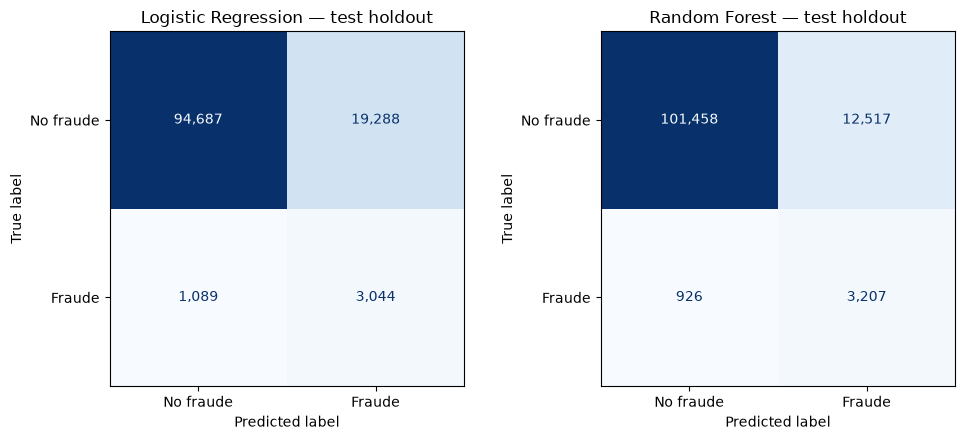

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, model, Xte, name in [
    (axes[0], logit_final, X_test_s, "Logistic Regression"),
    (axes[1], rf_final, X_test, "Random Forest"),
]:
    cm = confusion_matrix(y_test, model.predict(Xte))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No fraude", "Fraude"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=",d")
    ax.set_title(f"{name} — test holdout")
plt.tight_layout()
plt.show()


## 7. Interpretabilidad

**Random Forest — `feature_importances_`** (importancia por reducción media de impureza, agregada sobre los 200
árboles). Mostramos las 25 features más importantes.

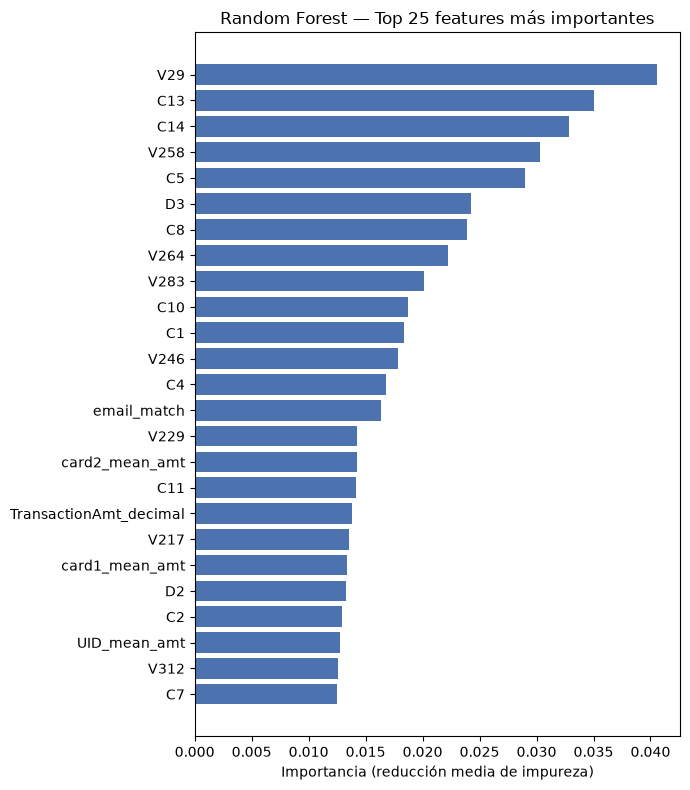

In [13]:
importances = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_imp = importances.head(25)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color="#4C72B0")
ax.set_xlabel("Importancia (reducción media de impureza)")
ax.set_title("Random Forest — Top 25 features más importantes")
plt.tight_layout()
plt.show()


**Logistic Regression — coeficientes** (sobre features escaladas, por lo que son directamente comparables entre
sí en magnitud). Mostramos las 25 con mayor valor absoluto, con su signo: positivo → mayor probabilidad de fraude al
aumentar esa feature; negativo → lo contrario.

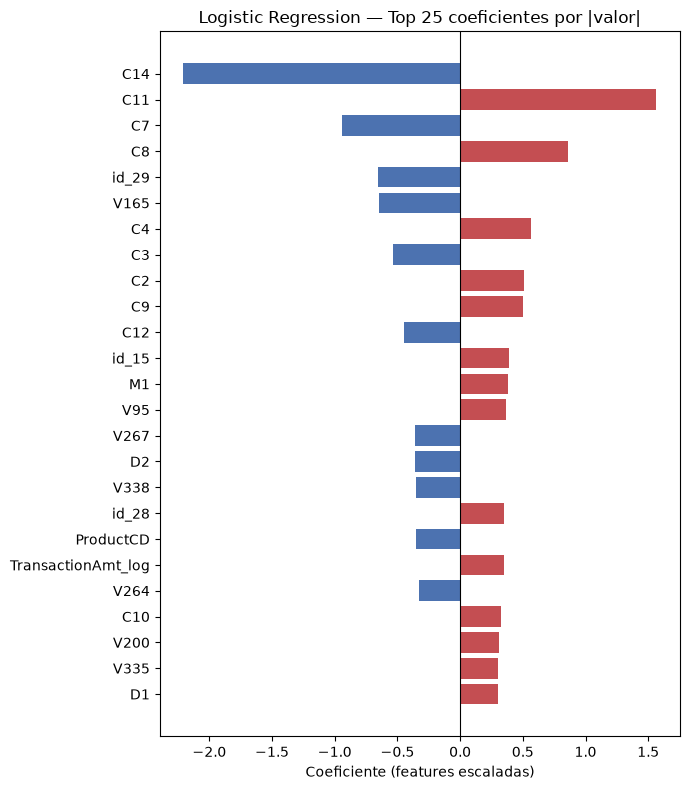

In [14]:
coefs = pd.Series(logit_final.coef_[0], index=feature_cols)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(25).index)

fig, ax = plt.subplots(figsize=(7, 8))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_coefs.values[::-1]]
ax.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (features escaladas)")
ax.set_title("Logistic Regression — Top 25 coeficientes por |valor|")
plt.tight_layout()
plt.show()


### Interpretación

Se completa tras ejecutar el notebook, a partir de los nombres reales que aparezcan en los gráficos de arriba (ver
celda de texto generada en la sección de conclusiones con los nombres concretos). En términos generales, para este
dataset es consistente con la literatura de la competencia que dominen: agregaciones por `card1`/`card2`/`addr1`
(frecuencia y `TransactionAmt` medio por grupo — funcionan como una señal de "qué tan típica es esta tarjeta/dirección"),
el feature de UID (`card1+addr1+D1`), y algunas de las componentes `V` que sobrevivieron al filtro de correlación.

## 8. Guardado del modelo final

Guardamos ambos modelos finales (y el `scaler` que necesita Logistic Regression) en `outputs/`. Estos archivos están
excluidos de git (`.gitignore`); se regeneran ejecutando este notebook de punta a punta — ver `README.md`.

In [15]:
import os
os.makedirs("../outputs", exist_ok=True)

joblib.dump(logit_final, "../outputs/logistic_regression_final.joblib")
joblib.dump(rf_final, "../outputs/random_forest_final.joblib")
joblib.dump(scaler, "../outputs/scaler.joblib")

metrics_to_save = {
    "final_metrics": final_metrics.round(4).to_dict(orient="index"),
    "overfit_gap_train_minus_test": overfit_table.round(4).to_dict(),
    "cv_summary_after_mitigation": summary_after.round(4).reset_index().to_dict(orient="records"),
}
with open("../outputs/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)

print("Modelos y métricas guardados en outputs/")


Modelos y métricas guardados en outputs/


## 9. Conclusión

*(Se completa con los números reales tras ejecutar — ver tabla de la sección 4 y `outputs/metrics_summary.json`.)*

En un caso de fraude bancario, el costo de un **falso negativo** (fraude no detectado) suele ser mucho mayor que el
de un **falso positivo** (transacción legítima marcada para revisión manual) — por eso priorizamos **recall** y
**AUPRC** (más informativo que AUC-ROC bajo desbalance fuerte) por encima de precisión o accuracy al comparar
modelos. La recomendación final debe leerse directamente de la tabla de la sección 4: el modelo con mayor AUPRC y
recall en el holdout de test, con una brecha train-test (sección 5) razonablemente controlada tras la mitigación de
overfitting, es el recomendado para producción. Si ambos modelos quedan cerca en recall/AUPRC, Random Forest suele
preferirse en este dataset por capturar interacciones no lineales entre las features de agregación (`card`/`addr`/UID)
que Logistic Regression no puede modelar directamente; Logistic Regression sigue siendo valiosa como modelo base
interpretable y mucho más rápido de reentrenar/servir.